Found 1595 images belonging to 6 classes.
Found 396 images belonging to 6 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 43s 579ms/step - accuracy: 0.7469 - loss: 0.7411 - val_accuracy: 0.9343 - val_loss: 0.1509
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 329ms/step - accuracy: 0.9834 - loss: 0.0708 - val_accuracy: 0.9899 - val_loss: 0.0319
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 332ms/step - accuracy: 0.9898 - loss: 0.0348 - val_accuracy: 0.9899 - val_loss: 0.0401
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 333ms/step - accuracy: 0.9883 - loss: 0.0399 - val_accuracy: 0.9949 - val_loss: 0.0211
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 336ms/step - accuracy: 0.9959 - loss: 0.0183 - val_accuracy: 0.9545 - val_loss: 0.1140
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 336ms/step - accuracy: 0.9941 - loss: 0.0198 - val_accuracy: 0.9697 - val_loss: 0.0799
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 337ms/step - accuracy: 0.9948 - loss: 0.0142 - val_accuracy: 0.9899 - val_loss: 0.0341
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 326ms/step - accuracy: 0.9926 - loss: 0.0217 - val_accu

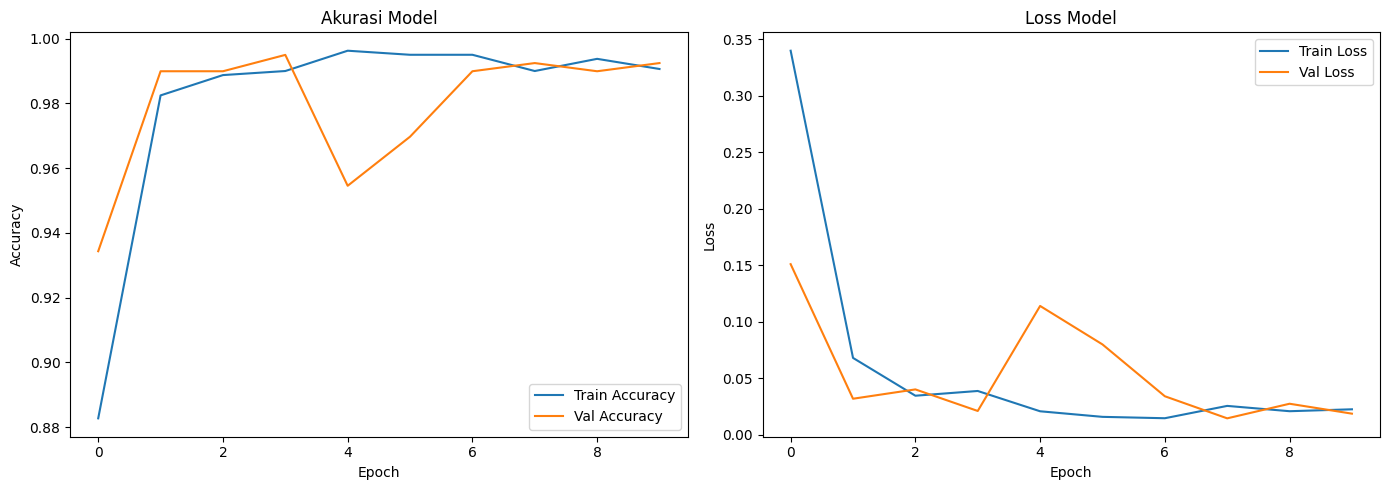

13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 644ms/step


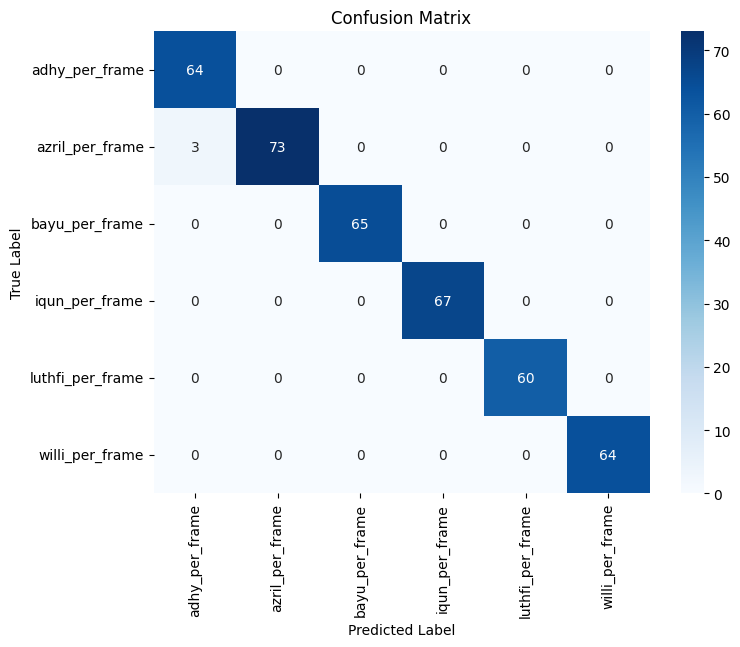

Classification Report:
                   precision    recall  f1-score   support

  adhy_per_frame       0.96      1.00      0.98        64
 azril_per_frame       1.00      0.96      0.98        76
  bayu_per_frame       1.00      1.00      1.00        65
  iqun_per_frame       1.00      1.00      1.00        67
luthfi_per_frame       1.00      1.00      1.00        60
 willi_per_frame       1.00      1.00      1.00        64

        accuracy                           0.99       396
       macro avg       0.99      0.99      0.99       396
    weighted avg       0.99      0.99      0.99       396



In [20]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Path dataset
dataset_path = '/kaggle/input/wajahdataset/Dataset'

# Parameter
img_height, img_width = 150, 150
batch_size = 32
epochs = 10

# Augmentasi dan preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

val_generator = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Label mapping
class_names = list(train_generator.class_indices.keys())

# Load InceptionV3 tanpa top layer
base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(img_height, img_width, 3)
)
base_model.trainable = False

# Bangun model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

# Kompilasi
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Training
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator
)

# Simpan model
# model.save('/kaggle/working/inception_face_classifier.h5')

# ====== Plot Akurasi dan Loss ======
plt.figure(figsize=(14, 5))

# Plot akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# ====== Evaluasi: Confusion Matrix dan Classification Report ======
# Prediksi data validasi
val_generator.reset()
pred_probs = model.predict(val_generator, verbose=1)
y_pred = np.argmax(pred_probs, axis=1)
y_true = val_generator.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n", report)


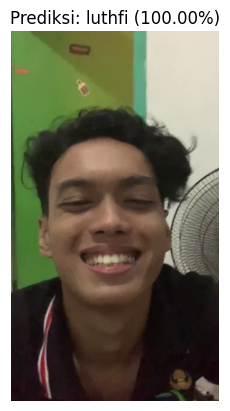

In [18]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.applications.inception_v3 import preprocess_input

# --- KONFIGURASI ---
model_path = '/kaggle/working/inception_face_classifier.h5'  # Ubah jika modelmu beda
image_path = '/kaggle/input/wajahdataset/Dataset/luthfi_per_frame/frame_00017.jpg'       # Ganti sesuai gambar uji
img_height, img_width = 150, 150                             # Ukuran sesuai saat training
class_names = ['adhy', 'azril', 'bayu', 'iqun', 'luthfi', 'willi']  # Urut sesuai train_generator.class_indices

# --- MUAT MODEL ---
model = tf.keras.models.load_model(model_path)

# --- BACA GAMBAR ---
image = cv2.imread(image_path)
if image is None:
    raise ValueError(f"Gambar tidak ditemukan di path: {image_path}")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_resized = cv2.resize(image_rgb, (img_width, img_height))
image_array = np.expand_dims(image_resized, axis=0)
image_array = preprocess_input(image_array)  # Untuk InceptionV3

# --- PREDIKSI ---
pred = model.predict(image_array, verbose=0)
pred_index = np.argmax(pred)
confidence = np.max(pred)
label = class_names[pred_index]

# --- TAMPILKAN HASIL ---
plt.imshow(image_rgb)
plt.axis('off')
plt.title(f'Prediksi: {label} ({confidence*100:.2f}%)')
plt.show()
